In [1]:
import json
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path("../data/structured/tmdb/movies")
EDA_DIR = Path("../data/eda")

EDA_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

print(f"Data directory: {DATA_DIR}")
print(f"EDA output directory: {EDA_DIR}")

Data directory: ..\data\structured\tmdb\movies
EDA output directory: ..\data\eda


In [2]:
movie_files = sorted(DATA_DIR.glob("*.json"))

print(f"Total JSON files found: {len(movie_files)}")
if len(movie_files) == 0:
    raise FileNotFoundError(
        f"No JSON files found in {DATA_DIR.resolve()}")

Total JSON files found: 539


In [3]:
movies = []
failed_files = []

for file_path in movie_files:
    try:
        with open(file_path, "r", encoding="utf-8") as f:
            movie = json.load(f)

        movie["_source_file"] = file_path.name
        movies.append(movie)

    except Exception as e:
        failed_files.append({
            "file": file_path.name,
            "error": str(e)
        })


print(f"Successfully loaded: {len(movies)}")
print(f"Failed to load:       {len(failed_files)}")

if failed_files:
    display(pd.DataFrame(failed_files))

Successfully loaded: 539
Failed to load:       0


In [4]:
print("First movie:")
print(json.dumps(movies[0], indent=2, ensure_ascii=False))

First movie:
{
  "movie_id": 1000866,
  "content": {
    "title": "The Marching Band",
    "original_title": "En fanfare",
    "overview": "A world-famous orchestra conductor discovers the brother he never knew he had — a school cafeteria worker who plays trombone in a local marching band. Detecting his brother's exceptional musical talent, he takes it upon himself to rectify the injustice of fate.",
    "tagline": ""
  },
  "embedding_text": "Title: The Marching Band\n\nOriginal Title: En fanfare\n\nOverview: A world-famous orchestra conductor discovers the brother he never knew he had — a school cafeteria worker who plays trombone in a local marching band. Detecting his brother's exceptional musical talent, he takes it upon himself to rectify the injustice of fate.\n\nGenres: Comedy, Drama, Music\n\nProduction Companies: Agat Films & Cie / Ex Nihilo, France 2 Cinéma, Greenwich Entertainment\n\nProduction Countries: France\n\nSpoken Languages: English, French, Italian",
  "metadata": 

In [5]:
EXPECTED_TOP_LEVEL = {
    "movie_id",
    "content",
    "embedding_text",
    "metadata",
    "relationships",
    "assets"
}

schema_issues = []

for movie in movies:
    movie_id = movie.get("movie_id")

    actual_keys = set(movie.keys())

    missing_keys = EXPECTED_TOP_LEVEL - actual_keys
    extra_keys = actual_keys - EXPECTED_TOP_LEVEL - {"_source_file"}

    if missing_keys or extra_keys:
        schema_issues.append({
            "movie_id": movie_id,
            "file": movie.get("_source_file"),
            "missing_keys": list(missing_keys),
            "extra_keys": list(extra_keys)
        })


schema_issues_df = pd.DataFrame(schema_issues)

print(f"Movies with top-level schema issues: {len(schema_issues_df)}")

if not schema_issues_df.empty:
    display(schema_issues_df)

Movies with top-level schema issues: 0


In [6]:
EXPECTED_CONTENT = {
    "title",
    "original_title",
    "overview",
    "tagline"
}

EXPECTED_METADATA = {
    "imdb_id",
    "release_date",
    "release_year",
    "original_language",
    "origin_country",
    "runtime_minutes",
    "status",
    "genres",
    "spoken_languages",
    "production_countries",
    "budget",
    "revenue",
    "popularity",
    "vote_average",
    "vote_count"
}

EXPECTED_RELATIONSHIPS = {
    "collection",
    "production_companies"
}

EXPECTED_ASSETS = {
    "homepage",
    "poster_path",
    "backdrop_path"
}


nested_schema_issues = []

for movie in movies:
    movie_id = movie.get("movie_id")

    for section_name, expected_keys in [
        ("content", EXPECTED_CONTENT),
        ("metadata", EXPECTED_METADATA),
        ("relationships", EXPECTED_RELATIONSHIPS),
        ("assets", EXPECTED_ASSETS),
    ]:
        section = movie.get(section_name)

        if not isinstance(section, dict):
            nested_schema_issues.append({
                "movie_id": movie_id,
                "section": section_name,
                "issue": "Section is not a dictionary"
            })
            continue

        missing = expected_keys - set(section.keys())

        if missing:
            nested_schema_issues.append({
                "movie_id": movie_id,
                "section": section_name,
                "issue": f"Missing keys: {list(missing)}"
            })


nested_schema_df = pd.DataFrame(nested_schema_issues)

print(f"Nested schema issues: {len(nested_schema_df)}")

if not nested_schema_df.empty:
    display(nested_schema_df)

Nested schema issues: 0


In [7]:
rows = []

for movie in movies:

    content = movie.get("content", {})
    metadata = movie.get("metadata", {})
    relationships = movie.get("relationships", {})
    assets = movie.get("assets", {})

    collection = relationships.get("collection")

    rows.append({
        "movie_id": movie.get("movie_id"),

        "title": content.get("title"),
        "original_title": content.get("original_title"),
        "overview": content.get("overview"),
        "tagline": content.get("tagline"),

        "embedding_text": movie.get("embedding_text"),

        "imdb_id": metadata.get("imdb_id"),
        "release_date": metadata.get("release_date"),
        "release_year": metadata.get("release_year"),
        "original_language": metadata.get("original_language"),
        "origin_country": metadata.get("origin_country"),
        "runtime_minutes": metadata.get("runtime_minutes"),
        "status": metadata.get("status"),

        "genres": metadata.get("genres"),
        "spoken_languages": metadata.get("spoken_languages"),
        "production_countries": metadata.get("production_countries"),

        "budget": metadata.get("budget"),
        "revenue": metadata.get("revenue"),
        "popularity": metadata.get("popularity"),
        "vote_average": metadata.get("vote_average"),
        "vote_count": metadata.get("vote_count"),

        "collection_id": (
            collection.get("id")
            if collection else None
        ),

        "collection_name": (
            collection.get("name")
            if collection else None
        ),

        "production_companies": relationships.get(
            "production_companies", []
        ),

        "homepage": assets.get("homepage"),
        "poster_path": assets.get("poster_path"),
        "backdrop_path": assets.get("backdrop_path"),

        "_source_file": movie.get("_source_file")
    })


df = pd.DataFrame(rows)

print(f"DataFrame shape: {df.shape}")

display(df.head())

DataFrame shape: (539, 28)


,movie_id,title,original_title,overview,tagline,embedding_text,imdb_id,release_date,release_year,original_language,origin_country,runtime_minutes,status,genres,spoken_languages,production_countries,budget,revenue,popularity,vote_average,vote_count,collection_id,collection_name,production_companies,homepage,poster_path,backdrop_path,_source_file
0,1000866,The Marching Band,En fanfare,A world-famous orchestra conductor discovers the brother he never knew he had — a school cafeter...,,Title: The Marching Band\n\nOriginal Title: En fanfare\n\nOverview: A world-famous orchestra con...,tt30327451,2024-11-27,2024.0,fr,[FR],102,Released,"[Comedy, Drama, Music]","[English, French, Italian]",[France],6100000,26252618,18.1222,7.300,523,NaN,NaN,"[{'id': 207, 'name': 'Agat Films & Cie / Ex Nihilo', 'origin_country': 'FR'}, {'id': 83, 'name':...",https://themarchingbandmovie.com/,/6lATJ42bWGAIQ0cG2dzSZD8bNcL.jpg,/fIbr7oWorx5rOzdjOiIFtfFUXzp.jpg,1000866.json
1,1001311,Under Paris,Sous la Seine,"In order to save Paris from an international bloodbath, a grieving scientist is forced to face h...",,Title: Under Paris\n\nOriginal Title: Sous la Seine\n\nOverview: In order to save Paris from an ...,tt13964390,2024-06-04,2024.0,fr,[FR],102,Released,"[Action, Horror]",[French],[France],0,0,7.9186,5.922,1459,1630649.0,Under Paris Collection,"[{'id': 220755, 'name': 'Let Me Be', 'origin_country': 'FR'}]",https://www.netflix.com/title/81210788,/qZPLK5ktRKa3CL4sKRZtj8UlPYc.jpg,/iwkWvcXcP8M4r9HLglhVEhgGyVu.jpg,1001311.json
2,1003596,Avengers: Doomsday,Avengers: Doomsday,Beloved heroes from three distinct universes are set on a deadly collision course and face an ex...,,Title: Avengers: Doomsday\n\nOverview: Beloved heroes from three distinct universes are set on a...,tt21357150,2026-12-16,2026.0,en,[US],165,Post Production,"[Science Fiction, Action, Adventure]",[English],[United States of America],0,0,78.0968,0.000,0,86311.0,The Avengers Collection,"[{'id': 420, 'name': 'Marvel Studios', 'origin_country': 'US'}, {'id': 176762, 'name': 'Kevin Fe...",https://www.marvel.com/movies/avengers-doomsday,/40jN1UgNAYEkGt2M0i81ghLF3cc.jpg,/s4v0UX1anfXm0UvloLsTTJ4v222.jpg,1003596.json
3,1007757,Swapped,Swapped,"A small woodland creature and a majestic bird, two natural sworn enemies of the Valley, magicall...",Transform your destiny.,Title: Swapped\n\nTagline: Transform your destiny.\n\nOverview: A small woodland creature and a ...,tt29552248,2026-05-01,2026.0,en,[US],102,Released,"[Adventure, Animation, Family, Fantasy]",[English],"[United States of America, Spain]",7,7,41.4363,8.900,2209,NaN,NaN,"[{'id': 115416, 'name': 'Skydance Animation', 'origin_country': 'US'}, {'id': 179999, 'name': 'S...",https://www.netflix.com/title/81749852,/tHhxWxge06goXU6ZQH1hj7vK8Hd.jpg,/zMwhWailP1WY7sb6AoE6b8ugoy.jpg,1007757.json
4,101,Léon: The Professional,Léon,"Léon, the top hit man in New York, has earned a rep as an effective ""cleaner"". But when his next...","If you want the job done right, hire a professional.",Title: Léon: The Professional\n\nOriginal Title: Léon\n\nTagline: If you want the job done right...,tt0110413,1994-09-14,1994.0,fr,[FR],111,Released,"[Crime, Drama, Action]","[English, French, Italian]",[France],16000000,20330788,25.4562,8.290,16568,NaN,NaN,"[{'id': 9, 'name': 'Gaumont', 'origin_country': 'FR'}, {'id': 66743, 'name': 'Les Films du Dauph...",,/bxB2q91nKYp8JNzqE7t7TWBVupB.jpg,/fj0hwDJEOOHllRim2BMt5L7tbjf.jpg,101.json


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 539 entries, 0 to 538
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   movie_id              539 non-null    int64  
 1   title                 539 non-null    str    
 2   original_title        539 non-null    str    
 3   overview              539 non-null    str    
 4   tagline               539 non-null    str    
 5   embedding_text        539 non-null    str    
 6   imdb_id               476 non-null    str    
 7   release_date          539 non-null    str    
 8   release_year          525 non-null    float64
 9   original_language     539 non-null    str    
 10  origin_country        539 non-null    object 
 11  runtime_minutes       539 non-null    int64  
 12  status                539 non-null    str    
 13  genres                539 non-null    object 
 14  spoken_languages      539 non-null    object 
 15  production_countries  539 non-null

In [9]:
numeric_columns = [
    "release_year",
    "runtime_minutes",
    "budget",
    "revenue",
    "popularity",
    "vote_average",
    "vote_count"
]

display(df[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
release_year,525.0,2.015126e+03,1.490861e+01,1954.0000,2010.0000,2.023000e+03,2.026000e+03,2.027000e+03
runtime_minutes,539.0,1.048831e+02,4.538033e+01,0.0000,90.5000,1.070000e+02,1.320000e+02,2.350000e+02
budget,539.0,3.969833e+07,6.801197e+07,0.0000,0.0000,4.500000e+06,5.000000e+07,3.560000e+08
revenue,539.0,2.033384e+08,4.120762e+08,0.0000,0.0000,1.004020e+07,2.071110e+08,2.923706e+09
popularity,539.0,3.802728e+01,5.754211e+01,0.0786,9.6483,2.514660e+01,4.333620e+01,6.877014e+02
vote_average,539.0,7.154221e+00,1.960646e+00,0.0000,6.5000,7.400000e+00,8.109500e+00,1.000000e+01
vote_count,539.0,4.610878e+03,8.031552e+03,0.0000,18.0000,6.630000e+02,4.466000e+03,4.129400e+04


In [10]:
ZERO_MEANS_MISSING = {
    "runtime_minutes",
    "budget",
    "revenue"
}

def zero_to_none(value):
    """
    TMDB uses 0 for some unavailable numeric fields.
    Treat 0 as missing.
    """
    if value == 0:
        return None

    return value

for col in ZERO_MEANS_MISSING:
    df[col] = df[col].apply(zero_to_none)

In [11]:
# verify that the NaN values have come in place

for col in ZERO_MEANS_MISSING:
    num_missing = df[col].isna().sum()
    print(f"{col}: {num_missing} missing values")

runtime_minutes: 23 missing values
revenue: 208 missing values
budget: 225 missing values


In [12]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (
        df.isna().mean() * 100
    ).round(2)
})

missing = missing.sort_values(
    "missing_percentage",
    ascending=False
)

display(missing)

,missing_count,missing_percentage
collection_id,343,63.64
collection_name,343,63.64
budget,225,41.74
revenue,208,38.59
imdb_id,63,11.69
backdrop_path,42,7.79
runtime_minutes,23,4.27
release_year,14,2.60
poster_path,3,0.56
original_title,0,0.00


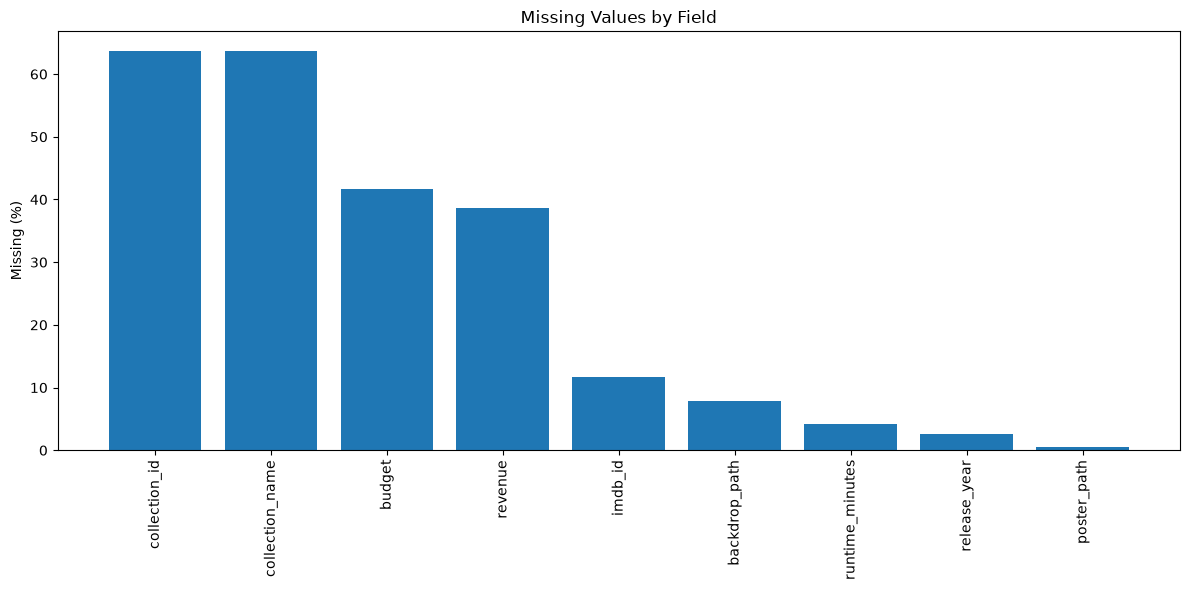

In [13]:
missing_nonzero = missing[
    missing["missing_count"] > 0
].copy()

if not missing_nonzero.empty:

    plt.figure(figsize=(12, 6))

    plt.bar(
        missing_nonzero.index,
        missing_nonzero["missing_percentage"]
    )

    plt.xticks(
        rotation=90
    )

    plt.ylabel("Missing (%)")
    plt.title("Missing Values by Field")
    plt.tight_layout()

    plt.show()

In [14]:
duplicate_ids = df[
    df["movie_id"].duplicated(keep=False)
].sort_values("movie_id")

print(f"Duplicate movie IDs: {len(duplicate_ids)}")

if not duplicate_ids.empty:
    display(duplicate_ids[
        ["movie_id", "title", "_source_file"]
    ])

Duplicate movie IDs: 0


In [15]:
duplicate_titles = df[
    df["title"].duplicated(keep=False)
].sort_values("title")

print(f"Rows with duplicate titles: {len(duplicate_titles)}")

if not duplicate_titles.empty:
    display(
        duplicate_titles[
            ["movie_id", "title", "release_year"]
        ]
    )

Rows with duplicate titles: 6


,movie_id,title,release_year
16,1058424,Hope,2026.0
323,255709,Hope,2013.0
14,1050035,Monster,2023.0
209,1569292,Monster,2027.0
166,1423191,Resident Evil,2026.0
212,1576,Resident Evil,2002.0


In [16]:
critical_fields = [
    "movie_id",
    "title",
    "overview",
    "embedding_text"
]

critical_issues = []

for field in critical_fields:

    missing_count = df[field].isna().sum()

    empty_count = (
        df[field]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    critical_issues.append({
        "field": field,
        "missing": missing_count,
        "empty": empty_count
    })


critical_issues_df = pd.DataFrame(critical_issues)

display(critical_issues_df)

,field,missing,empty
0,movie_id,0,0
1,title,0,0
2,overview,0,15
3,embedding_text,0,0


In [17]:
df["embedding_text_chars"] = (
    df["embedding_text"]
    .fillna("")
    .astype(str)
    .str.len()
)

df["embedding_text_words"] = (
    df["embedding_text"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

display(
    df[
        [
            "embedding_text_chars",
            "embedding_text_words"
        ]
    ].describe()
)

,embedding_text_chars,embedding_text_words
count,539.000000,539.000000
mean,519.517625,75.964750
std,167.002062,25.984351
min,26.000000,4.000000
25%,420.500000,61.000000
50%,519.000000,75.000000
75%,619.500000,91.000000
max,1066.000000,156.000000


In [18]:
short_embeddings = df[
    df["embedding_text_words"] < 10
].sort_values("embedding_text_words")

print(
    f"Movies with fewer than 10 words in embedding text: "
    f"{len(short_embeddings)}"
)

display(
    short_embeddings[
        [
            "movie_id",
            "title",
            "embedding_text"
        ]
    ].head(30)
)

Movies with fewer than 10 words in embedding text: 5


,movie_id,title,embedding_text
284,1781122,???,Title: ???\n\nOverview: 202?
242,1775219,Regras do Apartamento 606,Title: Regras do Apartamento 606
265,1778834,L'ultimo passo verso la libertà,Title: L'ultimo passo verso la libertà\n\nGenres: Drama
254,1776621,Changy Movie,"Title: Changy Movie\n\nGenres: Comedy, Horror\n\nProduction Countries: Germany"
285,1781256,Five nights at sonic,Title: Five nights at sonic\n\nOverview: October 15 2027


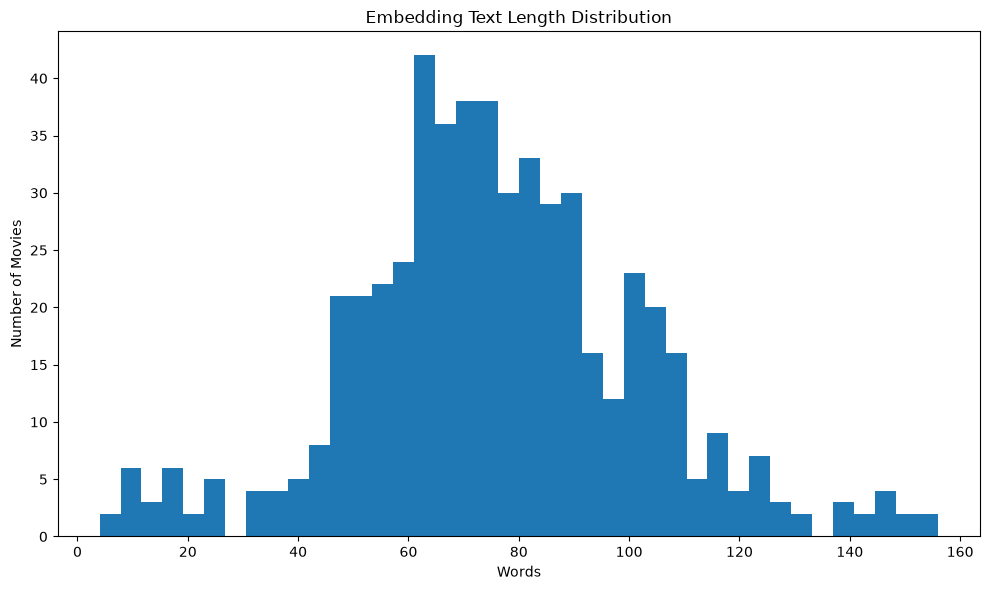

In [19]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["embedding_text_words"].dropna(),
    bins=40
)

plt.xlabel("Words")
plt.ylabel("Number of Movies")
plt.title("Embedding Text Length Distribution")

plt.tight_layout()
plt.show()

In [20]:
current_year = pd.Timestamp.now().year

invalid_years = df[
    (df["release_year"].notna()) &
    (
        (df["release_year"] < 1800) |
        (df["release_year"] > current_year+2)
    )
]

print(f"Invalid release years: {len(invalid_years)}")

if not invalid_years.empty:
    display(
        invalid_years[
            ["movie_id", "title", "release_year"]
        ]
    )

Invalid release years: 0


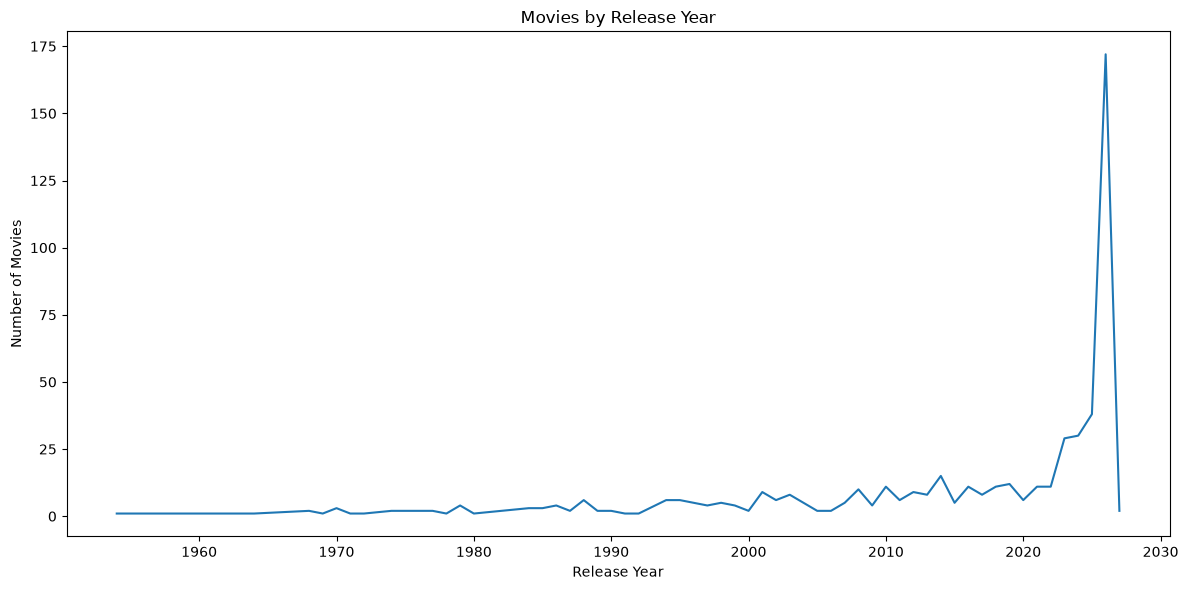

In [21]:
year_counts = (
    df["release_year"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    year_counts.index,
    year_counts.values
)

plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.title("Movies by Release Year")

plt.tight_layout()
plt.show()

In [22]:
invalid_runtime = df[
    (df["runtime_minutes"].notna()) &
    (
        (df["runtime_minutes"] <= 0) |
        (df["runtime_minutes"] > 500)
    )
]

print(f"Suspicious runtimes: {len(invalid_runtime)}")

if not invalid_runtime.empty:
    display(
        invalid_runtime[
            [
                "movie_id",
                "title",
                "runtime_minutes"
            ]
        ]
    )

Suspicious runtimes: 0


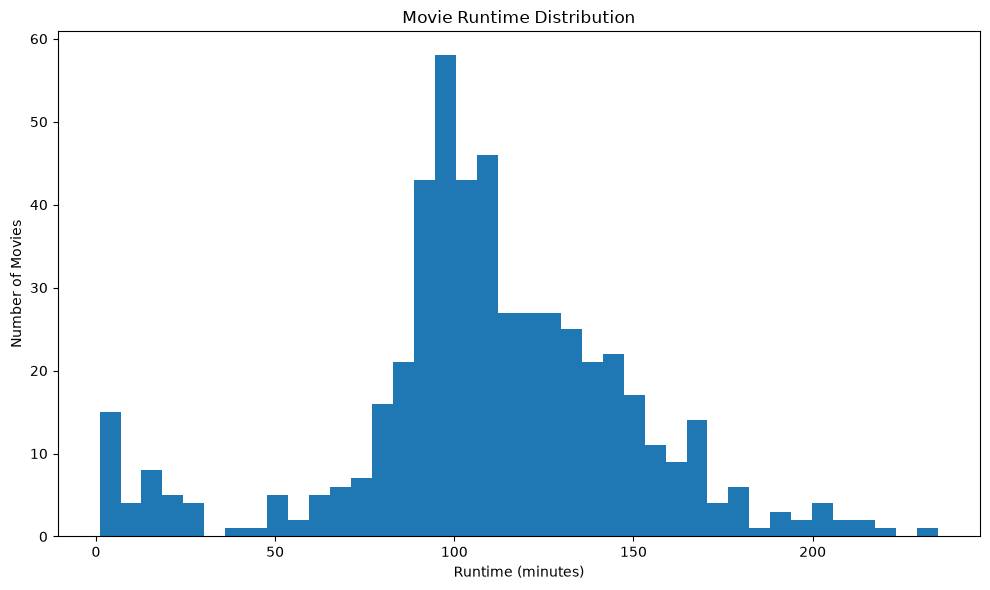

In [23]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["runtime_minutes"].dropna(),
    bins=40
)

plt.xlabel("Runtime (minutes)")
plt.ylabel("Number of Movies")
plt.title("Movie Runtime Distribution")

plt.tight_layout()
plt.show()

In [24]:
genre_series = (
    df["genres"]
    .dropna()
    .explode()
)

genre_counts = (
    genre_series
    .value_counts()
)

display(genre_counts)

genres
Drama              203
Action             157
Thriller           132
Comedy             129
Adventure          126
Science Fiction    101
Animation          100
Horror              93
Romance             86
Family              75
Fantasy             73
Crime               53
Mystery             42
Music               11
History              9
War                  8
Documentary          6
TV Movie             2
Western              1
Name: count, dtype: int64

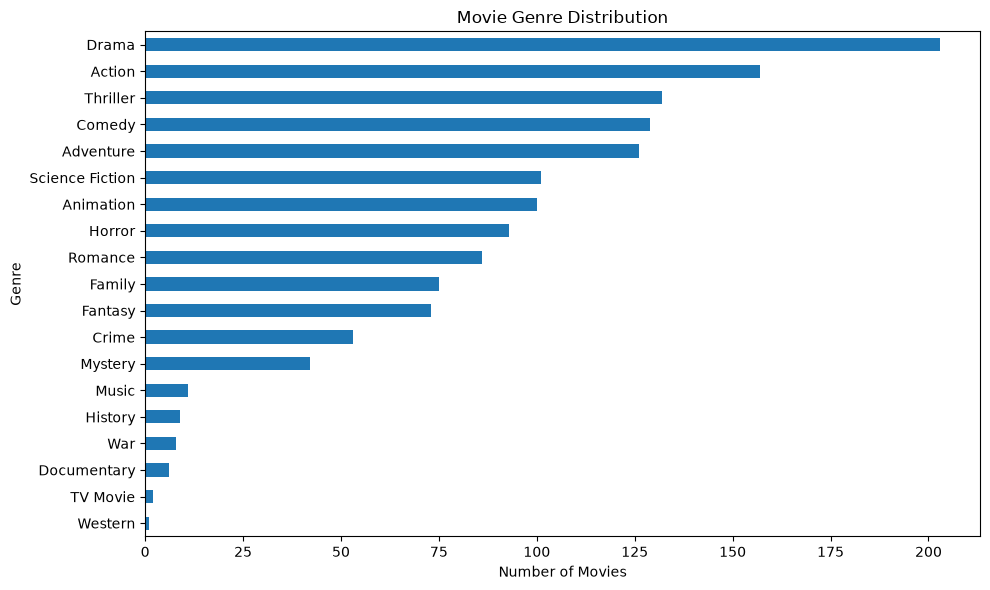

In [25]:
plt.figure(figsize=(10, 6))

genre_counts.sort_values().plot(
    kind="barh"
)

plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.title("Movie Genre Distribution")

plt.tight_layout()
plt.show()

In [26]:
language_counts = (
    df["original_language"]
    .value_counts()
)

display(language_counts.head(30))

original_language
en    256
ja     60
fr     58
hi     58
ko     57
es      9
zh      5
ta      5
pt      5
id      3
it      3
kn      3
ar      3
tl      2
tr      2
cs      2
no      1
sd      1
ru      1
xx      1
de      1
nl      1
et      1
el      1
Name: count, dtype: int64

In [27]:
spoken_language_counts = (
    df["spoken_languages"]
    .dropna()
    .explode()
    .value_counts()
)

display(
    spoken_language_counts.head(30)
)

spoken_languages
English        299
Japanese        74
French          69
Korean          61
Hindi           60
Spanish         38
Italian         28
German          17
Mandarin        16
Russian         13
Arabic           7
Latin            6
Portuguese       6
Tamil            6
Punjabi          4
Tagalog          4
Hungarian        3
Swedish          3
Indonesian       3
Urdu             3
No Language      3
Dutch            3
Xhosa            3
Kannada          3
Romanian         2
Thai             2
Persian          2
Turkish          2
Yiddish          2
Danish           2
Name: count, dtype: int64

In [28]:
country_counts = (
    df["production_countries"]
    .dropna()
    .explode()
    .value_counts()
)

display(
    country_counts.head(30)
)

production_countries
United States of America    234
France                       70
Japan                        66
India                        59
South Korea                  52
United Kingdom               48
Canada                       18
Germany                      18
Spain                        14
Belgium                      10
China                        10
Italy                         8
Australia                     7
Brazil                        6
New Zealand                   5
Indonesia                     4
Austria                       3
Argentina                     3
Ireland                       3
Mexico                        3
Hong Kong                     2
Poland                        2
Switzerland                   2
Russia                        2
Greece                        2
Turkey                        2
Sweden                        2
Hungary                       1
Vietnam                       1
Norway                        1
Name: count, dtype:

In [29]:
origin_country_counts = (
    df["origin_country"]
    .dropna()
    .explode()
    .value_counts()
)

display(
    origin_country_counts.head(30)
)

origin_country
US    236
IN     65
JP     60
KR     57
FR     55
GB     19
CA     10
ES      5
AU      5
BR      5
CN      4
ID      4
HK      3
AR      3
DE      3
IT      3
IE      2
PL      2
MX      2
PH      2
TR      2
CZ      2
LY      2
BE      1
NO      1
HN      1
DK      1
DO      1
PK      1
KG      1
Name: count, dtype: int64

In [30]:
invalid_ratings = df[
    (df["vote_average"].notna()) &
    (
        (df["vote_average"] < 0) |
        (df["vote_average"] > 10)
    )
]

print(f"Invalid ratings: {len(invalid_ratings)}")

if not invalid_ratings.empty:
    display(
        invalid_ratings[
            [
                "movie_id",
                "title",
                "vote_average"
            ]
        ]
    )

Invalid ratings: 0


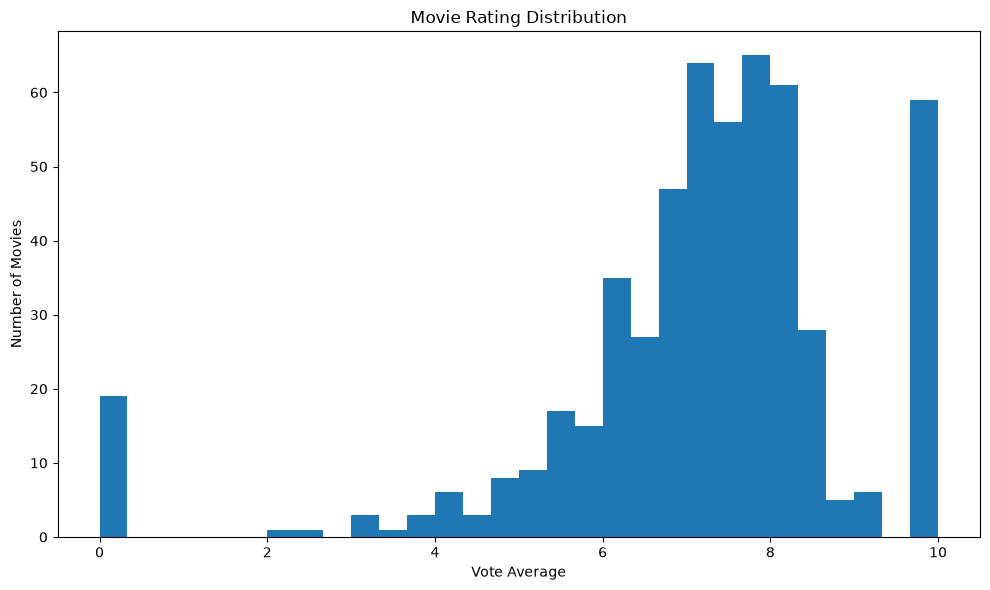

In [31]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["vote_average"].dropna(),
    bins=30
)

plt.xlabel("Vote Average")
plt.ylabel("Number of Movies")
plt.title("Movie Rating Distribution")

plt.tight_layout()
plt.show()

In [32]:
display(
    df["popularity"].describe()
)

count    539.000000
mean      38.027283
std       57.542112
min        0.078600
25%        9.648300
50%       25.146600
75%       43.336200
max      687.701400
Name: popularity, dtype: float64

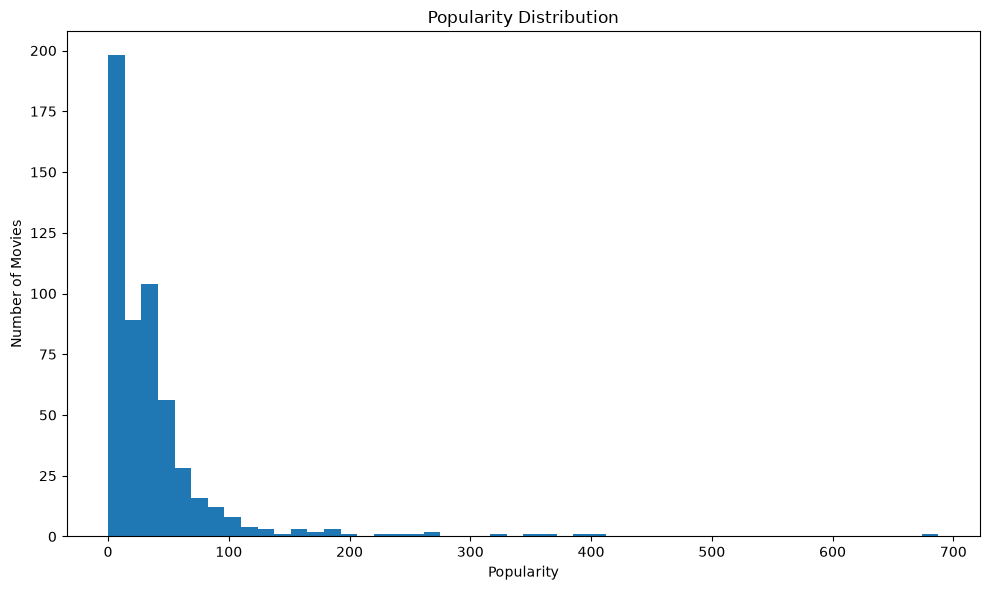

In [33]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["popularity"].dropna(),
    bins=50
)

plt.xlabel("Popularity")
plt.ylabel("Number of Movies")
plt.title("Popularity Distribution")

plt.tight_layout()
plt.show()

In [34]:
financial_columns = [
    "budget",
    "revenue"
]

display(
    df[financial_columns].describe().T
)

,count,mean,std,min,25%,50%,75%,max
budget,314.0,6.814458e+07,7.749908e+07,1.0,8716614.0,32500000.0,100000000.0,3.560000e+08
revenue,331.0,3.311160e+08,4.841478e+08,7.0,20912141.5,113763426.0,462750266.0,2.923706e+09


In [35]:
for column in ["budget", "revenue"]:

    zero_count = (df[column] == 0).sum()

    print(
        f"{column}: {zero_count} movies with value 0"
    )

budget: 0 movies with value 0
revenue: 0 movies with value 0


In [36]:
status_counts = (
    df["status"]
    .value_counts(dropna=False)
)

display(status_counts)

status
Released           530
Post Production      6
In Production        2
Planned              1
Name: count, dtype: int64

In [37]:
collection_count = (
    df["collection_name"]
    .notna()
    .sum()
)

total_movies = len(df)

print(
    f"Movies belonging to a collection: "
    f"{collection_count}/{total_movies}"
)

print(
    f"Percentage: "
    f"{collection_count / total_movies * 100:.2f}%"
)

Movies belonging to a collection: 196/539
Percentage: 36.36%


In [38]:
collection_counts = (
    df["collection_name"]
    .dropna()
    .value_counts()
)

display(
    collection_counts.head(30)
)

collection_name
The Avengers Collection                      5
Toy Story Collection                         5
Resident Evil (Animated) Collection          4
Shrek Collection                             3
28 Days/Weeks/Years Later Collection         3
Miraculous World                             3
The Lord of the Rings Collection             3
The Godfather Collection                     3
Cars Collection                              3
Spider-Man (MCU) Collection                  3
Iron Man Collection                          2
Inside Out Collection                        2
Back to the Future Collection                2
Zootopia Collection                          2
Frozen Collection                            2
PAW Patrol (Theatrical) Collection           2
Taare Zameen Par Collection                  2
The Super Mario Collection                   2
Dhurandhar Collection                        2
Practical Magic Collection                   2
Demon Slayer: Kimetsu no Yaiba Collection   

In [39]:
def contains_non_ascii(value):
    if pd.isna(value):
        return False

    return any(ord(char) > 127 for char in str(value))


df["title_has_unicode"] = df["title"].apply(
    contains_non_ascii
)

df["overview_has_unicode"] = df["overview"].apply(
    contains_non_ascii
)

print(
    "Titles containing non-ASCII characters:",
    df["title_has_unicode"].sum()
)

print(
    "Overviews containing non-ASCII characters:",
    df["overview_has_unicode"].sum()
)

Titles containing non-ASCII characters: 14
Overviews containing non-ASCII characters: 94


In [40]:
unicode_movies = df[
    df["title_has_unicode"]
]

display(
    unicode_movies[
        [
            "movie_id",
            "title",
            "original_title",
            "original_language"
        ]
    ].head(50)
)

,movie_id,title,original_title,original_language
4,101,Léon: The Professional,Léon,fr
22,10681,WALL·E,WALL·E,en
198,1525963,Debtor’s Wife,채무자의 아내,ko
219,1608457,누나 친구 4,누나 친구 4,ko
246,1775716,Výlov,Výlov,cs
249,1775736,Táta s Kozou v krabici,Táta s Kozou v krabici,cs
265,1778834,L'ultimo passo verso la libertà,L'ultimo passo verso la libertà,it
277,1780096,"D&D, but It’s Minecraft","D&D, but It’s Minecraft",en
281,1781022,O Mortífero Celular,O Mortífero Celular,pt
289,1781641,Diskol ja Võõrsil,Diskol ja Võõrsil,et


In [41]:
asset_columns = [
    "homepage",
    "poster_path",
    "backdrop_path"
]

asset_summary = pd.DataFrame({
    "available": df[asset_columns].notna().sum(),
    "missing": df[asset_columns].isna().sum(),
})

asset_summary["available_percentage"] = (
    asset_summary["available"]
    / len(df)
    * 100
).round(2)

display(asset_summary)

,available,missing,available_percentage
homepage,539,0,100.00
poster_path,536,3,99.44
backdrop_path,497,42,92.21


In [42]:
company_names = []

for companies in df["production_companies"].dropna():

    if isinstance(companies, list):

        for company in companies:

            if isinstance(company, dict):
                name = company.get("name")

                if name:
                    company_names.append(name)


company_counts = (
    pd.Series(company_names)
    .value_counts()
)

display(
    company_counts.head(30)
)

TOHO                                     20
Pixar                                    19
Warner Bros. Pictures                    18
Universal Pictures                       16
Marvel Studios                           15
Columbia Pictures                        15
TSG Entertainment                        13
Paramount Pictures                       13
Domain Entertainment                     11
Amazon MGM Studios                       10
Studio Ghibli                            10
New Line Cinema                          10
Yash Raj Films                            9
Walt Disney Animation Studios             9
Nippon Television Network Corporation     9
Tokuma Shoten                             8
CJ Entertainment                          8
Walt Disney Pictures                      8
dentsu                                    8
Blumhouse Productions                     8
France 2 Cinéma                           7
TF1 Films Production                      7
Legendary Pictures              

In [43]:
health_report = {
    "total_movies": len(df),

    "duplicate_movie_ids": int(
        df["movie_id"].duplicated().sum()
    ),

    "missing_titles": int(
        df["title"].isna().sum()
    ),

    "missing_overviews": int(
        df["overview"].isna().sum()
    ),

    "empty_embedding_text": int(
        df["embedding_text"]
        .fillna("")
        .str.strip()
        .eq("")
        .sum()
    ),

    "missing_release_dates": int(
        df["release_date"].isna().sum()
    ),

    "missing_runtime": int(
        df["runtime_minutes"].isna().sum()
    ),

    "missing_genres": int(
        df["genres"].apply(
            lambda x: not x if isinstance(x, list) else True
        ).sum()
    ),

    "missing_ratings": int(
        df["vote_average"].isna().sum()
    ),

    "unicode_titles": int(
        df["title_has_unicode"].sum()
    ),

    "movies_with_posters": int(
        df["poster_path"].notna().sum()
    ),

    "movies_with_backdrops": int(
        df["backdrop_path"].notna().sum()
    ),

    "movies_with_homepage": int(
        df["homepage"].notna().sum()
    )
}

health_report_df = pd.DataFrame(
    health_report.items(),
    columns=["metric", "value"]
)

display(health_report_df)

,metric,value
0,total_movies,539
1,duplicate_movie_ids,0
2,missing_titles,0
3,missing_overviews,0
4,empty_embedding_text,0
5,missing_release_dates,0
6,missing_runtime,23
7,missing_genres,15
8,missing_ratings,0
9,unicode_titles,14


In [44]:
health_report_df.to_csv(
    EDA_DIR / "dataset_health.csv",
    index=False
)

missing.to_csv(
    EDA_DIR / "missing_values.csv"
)

genre_counts.to_csv(
    EDA_DIR / "genre_distribution.csv"
)

language_counts.to_csv(
    EDA_DIR / "language_distribution.csv"
)

collection_counts.to_csv(
    EDA_DIR / "collection_distribution.csv"
)

print(f"EDA results saved to: {EDA_DIR}")

EDA results saved to: ..\data\eda


In [45]:
eda_csv = EDA_DIR / "movies_eda.csv"

df.to_csv(
    eda_csv,
    index=False,
    encoding="utf-8"
)

print(f"Saved: {eda_csv}")

Saved: ..\data\eda\movies_eda.csv
